# PVTT 数据采集周报 — 第六周

**项目：** Product Video Template Transfer (PVTT)  
**目标会议：** CVPR 2027  
**负责人：** 王洁怡 (wangjieyi)  
**周期：** 2026-03-23 ~ 2026-03-29  

---

## 任务完成情况

| 子任务 | 状态 | 说明 |
|--------|------|------|
| Amazon 数据扩展 | ✅ 已完成 | 33个新关键词, 865→1,155产品, 863→1,130视频 |
| Shopify 大规模扩展 | ✅ 已完成 | 4→24店铺, 1,477→3,181产品, 133→5,509视频 |
| 新增 cosmetics 品类 | ✅ 已完成 | 8个化妆品店铺(Kylie/Fenty/Glossier等), 584产品 |
| Shopify 视频服务器标准化 | ✅ 已完成 | 133视频→295片段 (1280×720, 24fps) |
| FFGO 训练数据集构建 | ✅ 已完成 | 200样本×8文件, 完整交付 |
| 数据上传服务器 | ✅ 已完成 | Amazon+Shopify 全部同步 |
| 研究方向文档 | ✅ 已完成 | 4个博士方向+申请建议 |

---

## 一、数据集大规模扩展

### 1.1 数据增长对比

| 指标 | Week 05 (03-22) | Week 06 (03-29) | 增长 |
|------|----------------|----------------|------|
| 产品数 | 2,342 | **4,336** | +85% |
| 视频数 | 996 | **6,639** | +567% |
| 图片数 | 12,222 | **22,919** | +88% |
| 品类数 | 7 | **8** | +cosmetics |
| Shopify 店铺 | 4 | **24** | +500% |
| 数据量 | ~6.9 GB | **~35 GB** | +400% |

### 1.2 各类别产品与视频数量

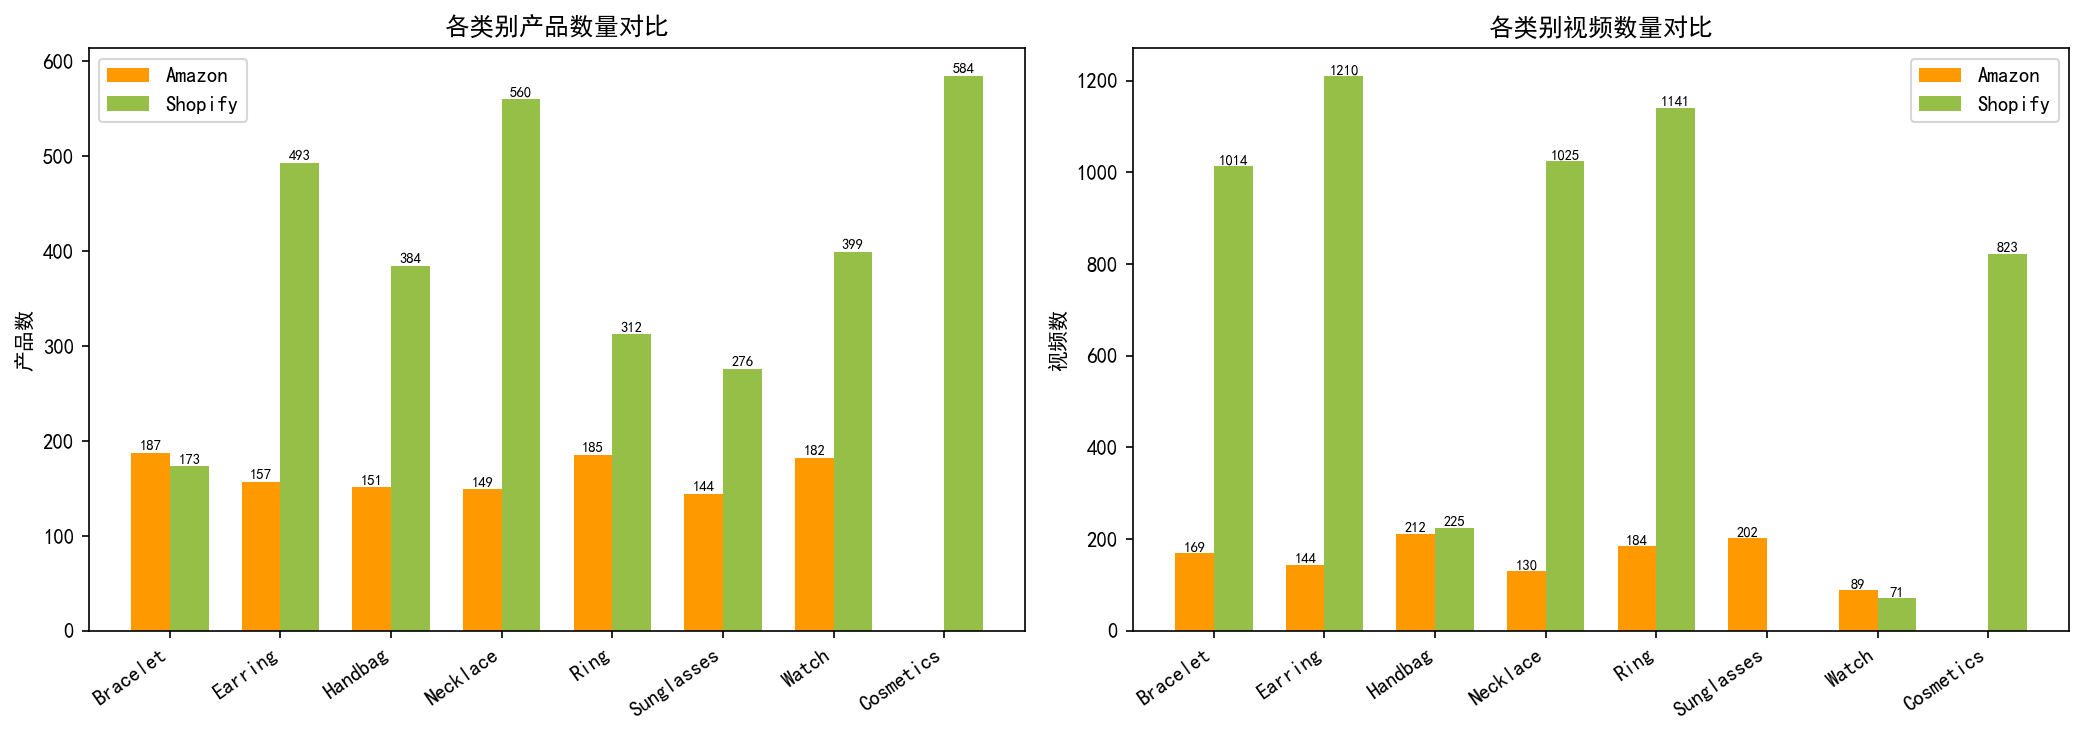

### 1.3 数据集增长趋势

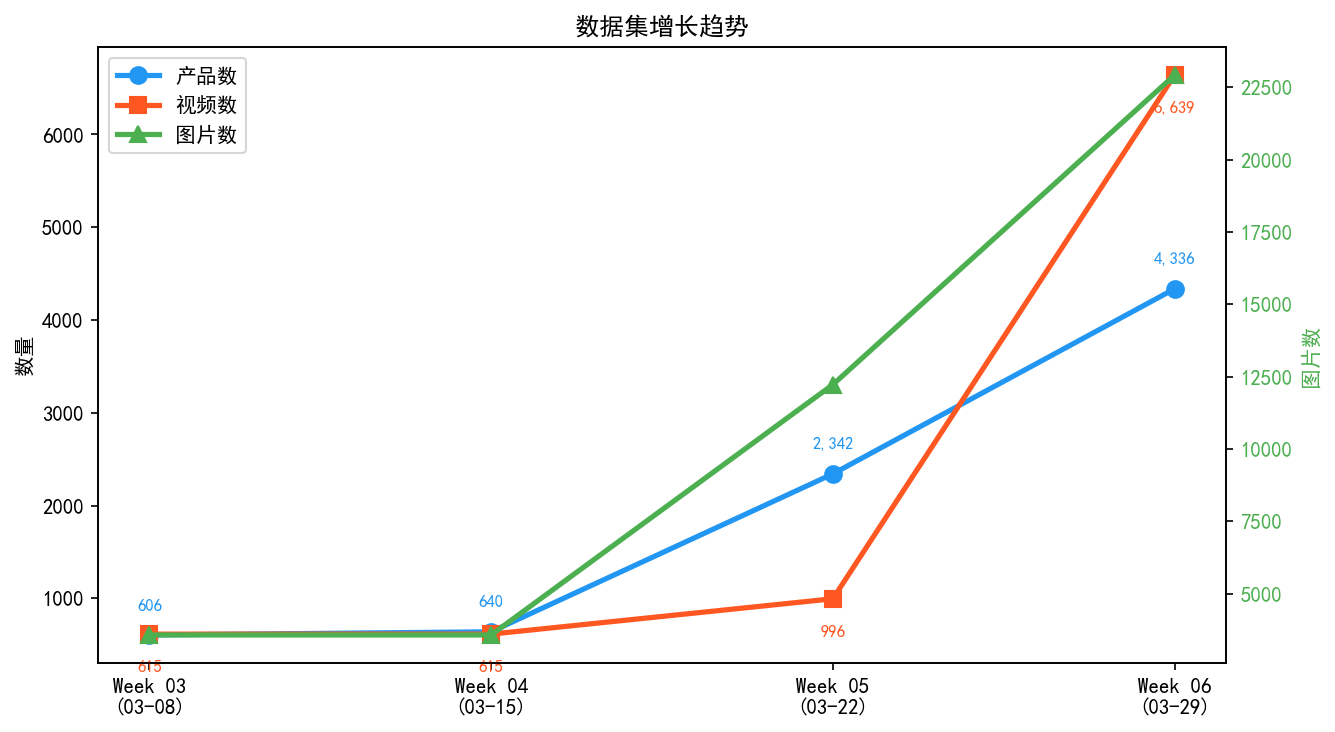

---

## 二、Shopify 大规模扩展

### 2.1 新增 20 个 Shopify 店铺

本周通过网络搜索发现并测试了 34 个新 Shopify 独立站，21 个 API 可用，成功采集 20 个：

| 品类 | 新增店铺 | 产品 | 视频 |
|------|---------|------|------|
| 珠宝 | karmaandluck, auratenewyork, ringconcierge | 470+ | 500+ |
| 手表 | xeric, triwa, shoreprojects, danielwellington, vincero, mrjones | 248 | 71 |
| 化妆品 | kylie, fenty, rarebeauty, colourpop, glossier, morphe, ilia, truebotanicals | 584 | 823 |
| 箱包 | rothys, calpaktravel, mansurgavriel | 192 | 225 |

### 2.2 Shopify 店铺分布

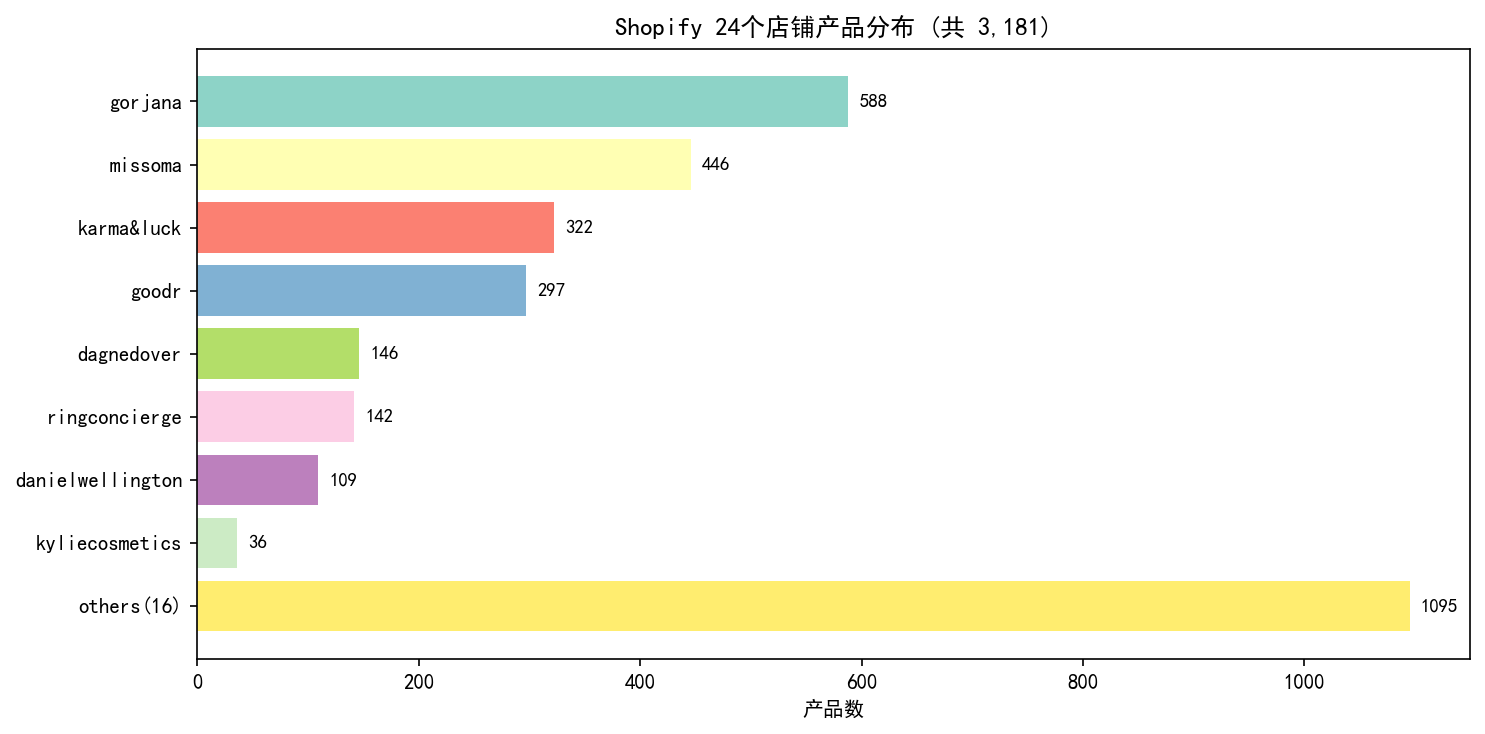

---

## 三、FFGO 训练数据集构建

### 3.1 数据集概述

为 FFGO LoRA 微调（Wan2.2 TI2V 5B）构建了完整的训练数据集：

| 指标 | 数值 |
|------|------|
| 样本数 | 200 |
| 每样本文件 | 8个 |
| 视频规格 | 832×480, 81帧, 16fps, H.264 |
| 来源 | Amazon 98 + Shopify 102 |
| 品类分布 | 8品类各25个 |

### 3.2 每个样本包含的文件

| 文件 | 说明 | 状态 |
|------|------|------|
| `video.mp4` | 目标视频 (832×480, 81帧, 16fps) | ✅ |
| `first_frame_raw.png` | 原始首帧（去padding） | ✅ |
| `product_rgba.png` | 产品RGBA透明背景 (isnet模型) | ✅ |
| `product_mask.png` | 产品掩码 | ✅ |
| `background.png` | 背景（产品移除后） | ✅ |
| `caption.txt` | 带触发词的描述文本 | ✅ |
| `first_frame.png` | FFGO拼合首帧（白色画布） | ✅ |
| `metadata.json` | 元信息 | ✅ |

**待改进：** 人物佩戴场景需 GroundingDINO+SAM2 精确提取产品; 背景修复需 LaMa 或 Gemini Pro

### 3.3 FFGO 数据集组成

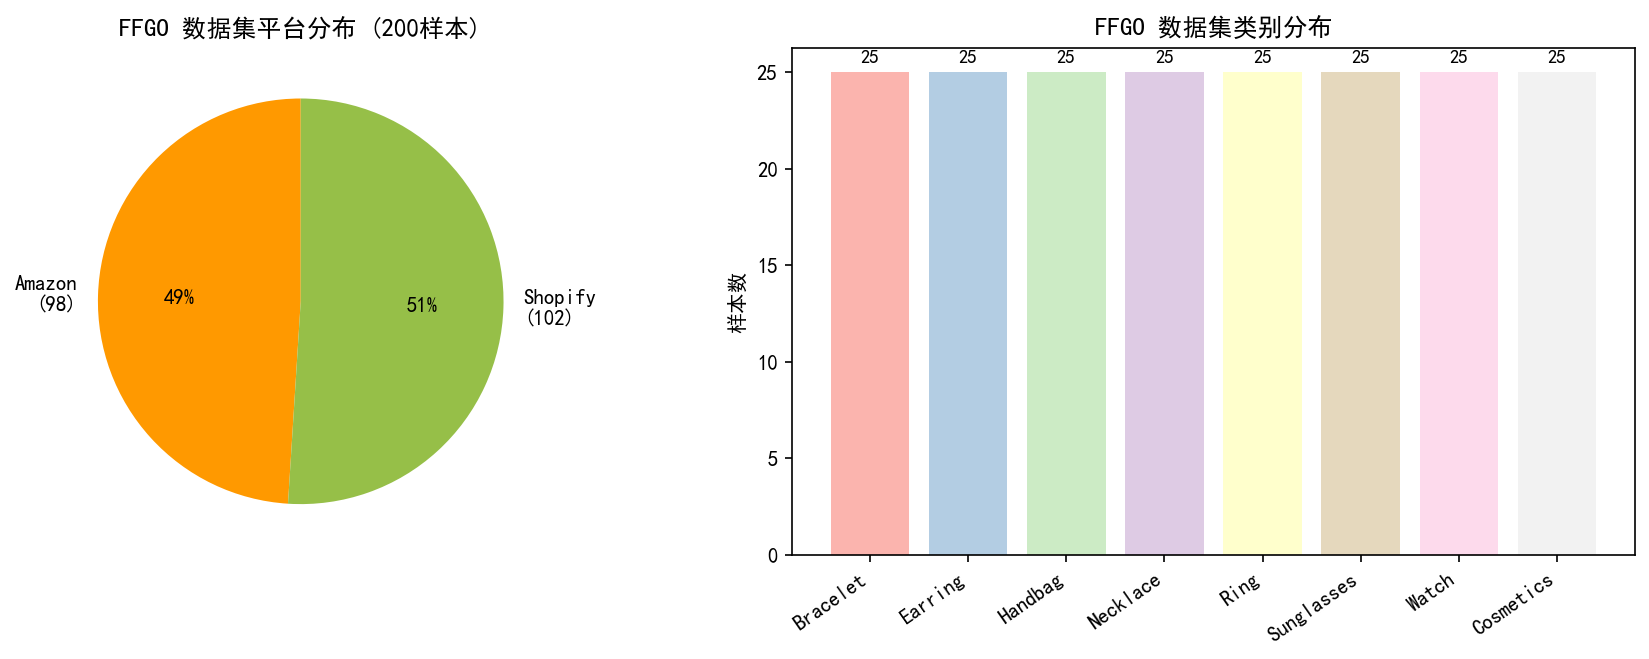

### 3.4 FFGO 处理流程

```
Step 1: 视频筛选 (6010→200) + 预处理 (832×480, 81帧, 16fps)     ✅
Step 2: 产品提取 (rembg isnet-general-use)                        ✅
Step 3: Caption (Gemini API 24个 + 模板 176个)                     ✅
Step 4: 背景提取 (cv2.inpaint NS多轮)                              ✅
Step 5: 首帧拼合 (白色画布, 左1/3产品 + 右2/3背景)                  ✅
Step 6: 验证 (200/200 完整, 0 issues)                              ✅
```

---

## 四、服务器工作

### 4.1 数据标准化

| 数据源 | 原始视频 | 标准化片段 |
|--------|---------|----------|
| Amazon | 1,130 | 5,258 |
| Shopify (首批) | 133 | 295 |
| **合计** | **1,263** | **5,553** |

新增的 5,500+ Shopify 视频待后续标准化。

### 4.2 环境问题

服务器 RTX 5090 (sm_120) 与 PyTorch stable 不兼容，需安装 nightly 版本。

---

## 五、遇到的问题与解决

| 问题 | 解决方案 |
|------|----------|
| Shopify 大店铺爬取超时 | 增大超时至 20min, 分轮爬取 |
| Gemini API 每日限额仅 20 次 | 模板 caption 替代, 分多天续跑 |
| Gemini 图像编辑免费额度为 0 | cv2.inpaint 替代 |
| RTX 5090 不兼容 PyTorch | CPU 模式运行, 后续装 nightly |
| C 盘空间不足 | 模型缓存迁移至 D 盘 |
| GroundingDINO 依赖冲突 | 降级 transformers 至 4.38.2 |

---

## 六、下周计划 (Week 07: 03-30 ~ 04-05)

| 任务 | 优先级 | 说明 |
|------|--------|------|
| FFGO 质量改进 | P0 | PyTorch nightly → GroundingDINO+LaMa GPU 加速 |
| Gemini caption 补生成 | P1 | 新 API key, 每天 20 个 |
| 新 Shopify 视频标准化 | P1 | 5,500+ 视频 → 服务器处理 |
| Amazon 继续扩展 | P2 | 目标 1,500+ 产品 |

---

## 七、数据集统计汇总

| 平台 | 产品 | 图片 | 视频 | 店铺 |
|------|------|------|------|------|
| Amazon | 1,155 | 6,391 | 1,130 | 1 |
| Shopify | 3,181 | 16,528 | 5,509 | 24 |
| **合计** | **4,336** | **22,919** | **6,639** | **25** |

**FFGO 训练集:** 200 样本 × 8 文件, 已推送 GitHub

**服务器标准化:** 5,553 片段 (1280×720, 24fps, H.264)

---
*PVTT 数据采集周报 — Week 06 — Product Video Template Transfer (CVPR 2027)*